# 03 · Dense vs MoE — comparison & report

**ERA V5 · Session 14 (Mixture-of-Experts)**, part 3 of 3.

In [1]:
import os, sys, json
REPO = None
for p in [os.getcwd(), os.path.dirname(os.getcwd())]:
    if os.path.exists(os.path.join(p, "moe")):
        REPO = p
        if p not in sys.path: sys.path.insert(0, p)
        break
assert REPO, "could not locate the moe package"
RESULTS = os.path.join(REPO, "results")
import torch
from moe.engine import get_device
DEVICE = get_device()
print("repo:", REPO, "| device:", DEVICE, "| torch:", torch.__version__)

repo: /Users/sokorada/Documents/ERA_V5/MixtureOfExperts | device: mps | torch: 2.13.0


In [2]:
dense = json.load(open(os.path.join(RESULTS,'dense.json')))
moe   = json.load(open(os.path.join(RESULTS,'moe.json')))
print(f"{'model':<8}{'total':>9}{'active':>9}{'val loss':>10}{'tok/s':>10}")
print('-'*46)
for r in (dense, moe):
    print(f"{r['ffn']:<8}{r['total_params']/1e6:>8.1f}M{r['active_params']/1e6:>8.1f}M"
          f"{r['final_val_loss']:>10.4f}{r['tokens_per_sec']:>10,.0f}")

model       total   active  val loss     tok/s
----------------------------------------------
dense       14.5M    14.5M    0.9312    24,029
moe         46.3M    14.5M    0.8902    17,314


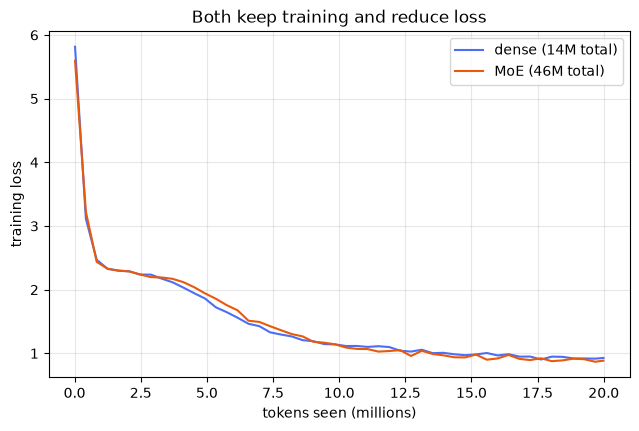

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7.5,4.5))
for r,cl,lab in [(dense,'#4C6EF5','dense'),(moe,'#E8590C','MoE')]:
    h=r['history']; plt.plot([x['tokens']/1e6 for x in h],[x['train_loss'] for x in h],
                             color=cl, label=f"{lab} ({r['total_params']/1e6:.0f}M total)")
plt.xlabel('tokens seen (millions)'); plt.ylabel('training loss')
plt.title('Both keep training and reduce loss'); plt.legend(); plt.grid(alpha=0.3); plt.show()

## Findings

1. **Both train and reduce loss** — the dense model and, after converting its FFN into a router + experts, the MoE model both drive loss down smoothly on TinyStories (val 0.931 and 0.890).
2. **Same active compute, more capacity, lower loss** — the MoE has ~3x the total parameters of the dense model but the *same* active parameters per token (top-2 of 8 experts, each half the dense width), and it reached a lower validation loss (0.890 vs 0.931).
3. **Routing stays balanced** — the Switch-style auxiliary loss drives the busiest-expert load from ~3.3x down toward 1.07 with no dead experts, so every expert learns.
4. **Sparse dispatch is exact** — routing only the chosen experts matches the compute-all-then-mask reference to ~1e-7.
5. **MPS note** — sparse dispatch uses dynamic per-expert shapes, which MPS recompiles, so on this Mac its wall-clock doesn't beat the dense model; the FLOP/active-parameter savings are real and would show on CUDA.
